In [1]:
import pandas as pd
import os, re, glob, shutil

In [2]:
current_dir = os.getcwd()
start_kit_dir = current_dir + '/start_kit'

Load the `json` into DataFrame.

In [3]:
json_dir = start_kit_dir +'/WLASL_v0.3.json'

df = pd.read_json(json_dir)
df_exploded = df.explode("instances", ignore_index=True)
df_flat = pd.concat(
    [df_exploded.drop(columns=["instances"]),
     pd.json_normalize(df_exploded["instances"])],
    axis=1
)
df_flat.head()

,gloss,bbox,fps,frame_end,frame_start,instance_id,signer_id,source,split,url,variation_id,video_id
0,book,"[385, 37, 885, 720]",25,-1,1,0,118,aslbrick,train,http://aslbricks.org/New/ASL-Videos/book.mp4,0,69241
1,book,"[190, 25, 489, 370]",25,-1,1,1,90,aslsignbank,train,https://aslsignbank.haskins.yale.edu/dictionar...,0,65225
2,book,"[262, 1, 652, 480]",25,-1,1,2,110,valencia-asl,train,https://www.youtube.com/watch?v=0UsjUE-TXns,0,68011
3,book,"[123, 19, 516, 358]",25,60,1,3,113,lillybauer,train,https://www.youtube.com/watch?v=1QOYOZ3g-aY,0,68208
4,book,"[95, 0, 1180, 720]",25,-1,1,4,109,valencia-asl,train,https://www.youtube.com/watch?v=aGtIHKEdCds,0,68012


In [4]:
df_flat.columns.to_list()

['gloss',
 'bbox',
 'fps',
 'frame_end',
 'frame_start',
 'instance_id',
 'signer_id',
 'source',
 'split',
 'url',
 'variation_id',
 'video_id']

### JSON - Data Analysis

In [5]:
df_flat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21083 entries, 0 to 21082
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   gloss         21083 non-null  object
 1   bbox          21083 non-null  object
 2   fps           21083 non-null  int64 
 3   frame_end     21083 non-null  int64 
 4   frame_start   21083 non-null  int64 
 5   instance_id   21083 non-null  int64 
 6   signer_id     21083 non-null  int64 
 7   source        21083 non-null  object
 8   split         21083 non-null  object
 9   url           21083 non-null  object
 10  variation_id  21083 non-null  int64 
 11  video_id      21083 non-null  object
dtypes: int64(6), object(6)
memory usage: 1.9+ MB


#### Q1: Find out the total number of videos in this dataset.

In [6]:
print(f"Total number of videos: {df_flat.shape[0]}")

Total number of videos: 21083


#### Q2: How many glosses are there in this dataset?

In [7]:
print(f"Total number of glosses: {df_flat['gloss'].unique().shape[0]}")

Total number of glosses: 2000


#### Q3: Which are the top-N most frequent gloss?

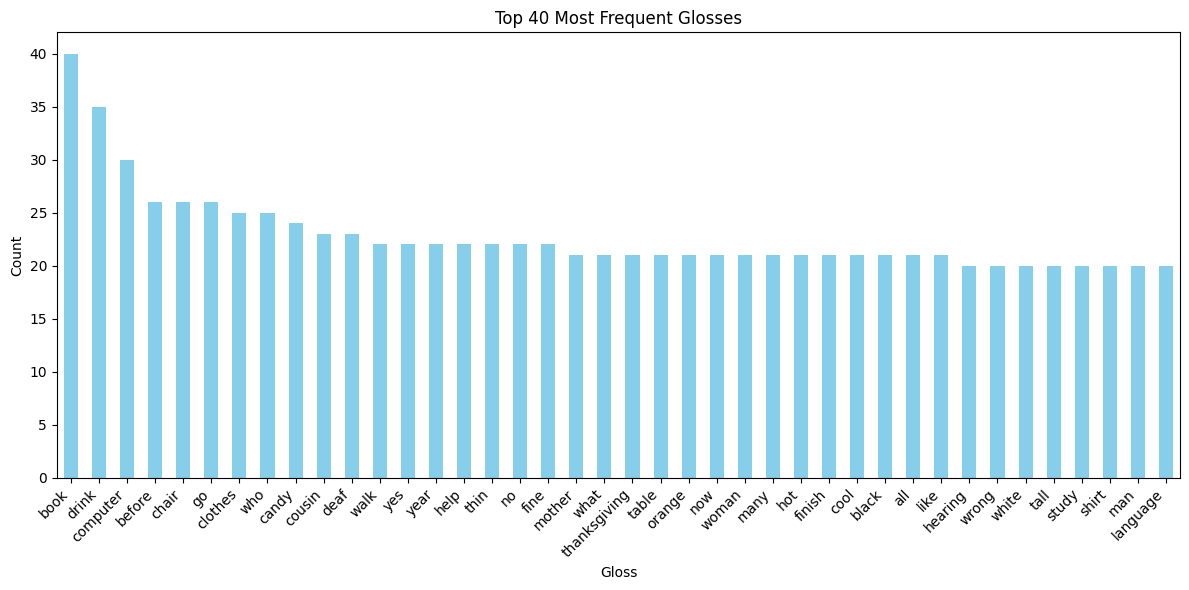

In [8]:
import matplotlib.pyplot as plt

gloss_counts = df_flat["gloss"].value_counts()

top_n = 40
gloss_counts.head(top_n).plot(kind="bar", figsize=(12,6), color="skyblue")
plt.title(f"Top {top_n} Most Frequent Glosses")
plt.xlabel("Gloss")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Q4: Which are the top-N least frequent gloss?

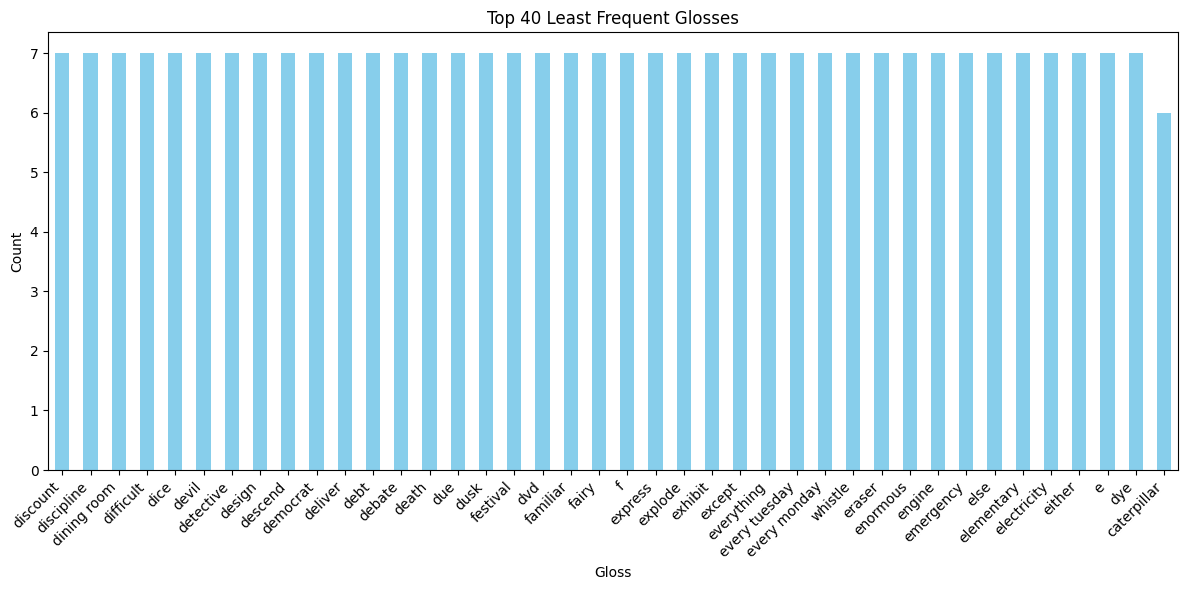

In [9]:
import matplotlib.pyplot as plt

gloss_counts = df_flat["gloss"].value_counts()

top_n = 40
gloss_counts.tail(top_n).plot(kind="bar", figsize=(12,6), color="skyblue")
plt.title(f"Top {top_n} Least Frequent Glosses")
plt.xlabel("Gloss")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [14]:
!pip install openai
import os
os.environ["OPENAI_API_KEY"] = ""



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### Create Gloss Count 

In [19]:
"""
Build gloss_video_counts.json from WLASL_v0.3.json.
Counts the number of video instances per gloss.
Saves to start_kit/categories/
"""
import json
from pathlib import Path

WLASL_JSON = start_kit_dir + "/WLASL_v0.3.json"
OUTPUT_JSON = start_kit_dir + "/categories/gloss_video_counts.json"

with open(WLASL_JSON) as f:
    wlasl = json.load(f)

gloss_counts = {}
for entry in wlasl:
    gloss = entry["gloss"]
    count = len(entry.get("instances", []))
    gloss_counts[gloss] = count

Path(OUTPUT_JSON).parent.mkdir(parents=True, exist_ok=True)
with open(OUTPUT_JSON, "w") as f:
    json.dump(gloss_counts, f, indent=2)
print(f"Saved to {OUTPUT_JSON}")

total_glosses = len(gloss_counts)
total_videos = sum(gloss_counts.values())
print(f"\nTotal glosses: {total_glosses}")
print(f"Total video instances: {total_videos}")
print(f"Top 5 by count: {sorted(gloss_counts.items(), key=lambda x: -x[1])[:5]}")

Saved to /Users/sritampatnaik/Masters/NUS-ISS Sritam/NUS-ISS Sem 3/Sign-Lang-v2/Datasets/WLASL/start_kit/categories/gloss_video_counts.json

Total glosses: 2000
Total video instances: 21083
Top 5 by count: [('book', 40), ('drink', 35), ('computer', 30), ('before', 26), ('chair', 26)]


## Classify Gloss Using OpenAI

In [20]:
"""
Classify WLASL glosses into categories using OpenAI API.
Requires OPENAI_API_KEY in environment or set below.
"""
import json
import os
import time
from pathlib import Path

from openai import OpenAI

CATEGORIES = [
    "people_family",
    "animals",
    "food_drink",
    "actions_verbs",
    "objects",
    "colors",
    "places",
    "time_numbers",
    "emotions_adjectives",
    "body_health",
    "clothing",
    "sports_activities",
    "abstract_concepts",
    "greetings_social",
    "other",
]

# Use start_kit_dir from notebook
GLOSS_JSON = start_kit_dir + "/categories/gloss_video_counts.json"
OUTPUT_JSON = start_kit_dir + "/categories/gloss_categories.json"
PROGRESS_JSON = start_kit_dir + "/categories/gloss_categories_progress.json"


def load_glosses(path: str) -> list:
    with open(path) as f:
        data = json.load(f)
    return list(data.keys())


def classify_gloss(client: OpenAI, gloss: str) -> str:
    prompt = f"""Classify this American Sign Language (ASL) gloss into exactly one category.

Gloss: "{gloss}"

Categories: {', '.join(CATEGORIES)}

Respond with ONLY the category name, nothing else."""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
    )
    result = response.choices[0].message.content.strip().lower()
    result = result.replace(" ", "_")
    if result not in CATEGORIES:
        result = "other"
    return result


# Run classification
api_key = os.environ.get("OPENAI_API_KEY")
if not api_key:
    raise SystemExit("Set OPENAI_API_KEY environment variable (or os.environ['OPENAI_API_KEY'] = 'your_key')")

client = OpenAI(api_key=api_key)
glosses = load_glosses(GLOSS_JSON)

results = {}
if Path(PROGRESS_JSON).exists():
    with open(PROGRESS_JSON) as f:
        results = json.load(f)
    print(f"Resuming: {len(results)} already classified")

for i, gloss in enumerate(glosses):
    if gloss in results:
        continue

    try:
        category = classify_gloss(client, gloss)
        results[gloss] = category
        print(f"[{i+1}/{len(glosses)}] {gloss} -> {category}")

        if (i + 1) % 10 == 0:
            with open(PROGRESS_JSON, "w") as f:
                json.dump(results, f, indent=2)
    except Exception as e:
        print(f"Error for '{gloss}': {e}")
        time.sleep(2)
        continue

    time.sleep(0.2)

with open(OUTPUT_JSON, "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved to {OUTPUT_JSON}")

from collections import Counter
counts = Counter(results.values())
print("\nCategory summary:")
for cat, n in counts.most_common():
    print(f"  {cat}: {n}")

[1/2000] book -> objects
[2/2000] drink -> food_drink
[3/2000] computer -> objects
[4/2000] before -> time_numbers
[5/2000] chair -> objects
[6/2000] go -> actions_verbs
[7/2000] clothes -> clothing
[8/2000] who -> other
[9/2000] candy -> food_drink
[10/2000] cousin -> people_family
[11/2000] deaf -> people_family
[12/2000] fine -> emotions_adjectives
[13/2000] help -> actions_verbs
[14/2000] no -> other
[15/2000] thin -> emotions_adjectives
[16/2000] walk -> actions_verbs
[17/2000] year -> time_numbers
[18/2000] yes -> greetings_social
[19/2000] all -> abstract_concepts
[20/2000] black -> colors
[21/2000] cool -> emotions_adjectives
[22/2000] finish -> actions_verbs
[23/2000] hot -> food_drink
[24/2000] like -> actions_verbs
[25/2000] many -> time_numbers
[26/2000] mother -> people_family
[27/2000] now -> time_numbers
[28/2000] orange -> colors
[29/2000] table -> objects
[30/2000] thanksgiving -> food_drink
[31/2000] what -> other
[32/2000] woman -> people_family
[33/2000] bed -> obje

In [21]:
import json
from collections import Counter

with open("start_kit/categories/gloss_categories.json") as f:
    gloss_categories = json.load(f)

category_counts = Counter(gloss_categories.values())

print("Gloss count per category:")
for cat, count in category_counts.most_common():
    print(f"  {cat}: {count}")
print(f"\nTotal glosses: {sum(category_counts.values())}")

Gloss count per category:
  actions_verbs: 533
  objects: 297
  abstract_concepts: 273
  emotions_adjectives: 167
  places: 132
  other: 125
  food_drink: 101
  time_numbers: 96
  people_family: 89
  animals: 61
  body_health: 53
  sports_activities: 29
  colors: 19
  clothing: 15
  greetings_social: 10

Total glosses: 2000


In [25]:
import json

WLASL_JSON = "start_kit/WLASL_v0.3.json"
CATEGORIES_JSON = "start_kit/categories/gloss_categories.json"
GLOSS_COUNTS_JSON = "start_kit/categories/gloss_video_counts.json"

# Load data
with open(WLASL_JSON) as f:
    wlasl = json.load(f)
with open(CATEGORIES_JSON) as f:
    gloss_categories = json.load(f)
with open(GLOSS_COUNTS_JSON) as f:
    gloss_video_counts = json.load(f)

# 1. Pick a category and list glosses with video counts
category = "places"  # change as needed

glosses_in_category = [
    (gloss, gloss_video_counts.get(gloss, 0))
    for gloss, cat in gloss_categories.items()
    if cat == category
]
glosses_in_category.sort(key=lambda x: -x[1])  # sort by count descending

# print(f"Category: {category} ({len(glosses_in_category)} glosses)\n")
# print("Gloss | Videos")
# print("-" * 25)
# for gloss, count in glosses_in_category:
#     print(f"  {gloss:20} {count}")

# 2. Select glosses (edit this list)
selected_glosses = ["school", "africa", "city", "room", "bathroom", "college", "home", "country", "here", "office", "party", "restaurant", "russia", "south", "where", "behind", "east", "north", "west", "australia", "basement", "cafeteria", "church", "hospital", "japan"]  # add/remove as needed

# 3. Build subset and save
subset = [entry for entry in wlasl if entry["gloss"] in selected_glosses]

output_path = "start_kit/categories/WLASL_places_subset.json"
with open(output_path, "w") as f:
    json.dump(subset, f, indent=2)

total_videos = sum(len(e["instances"]) for e in subset)
print(f"Selected glosses: {selected_glosses}")
print(f"Glosses in subset: {len(subset)}")
print(f"Total videos: {total_videos}")
print(f"Saved to: {output_path}")

Selected glosses: ['school', 'africa', 'city', 'room', 'bathroom', 'college', 'home', 'country', 'here', 'office', 'party', 'restaurant', 'russia', 'south', 'where', 'behind', 'east', 'north', 'west', 'australia', 'basement', 'cafeteria', 'church', 'hospital', 'japan']
Glosses in subset: 25
Total videos: 374
Saved to: start_kit/categories/WLASL_places_subset.json


## Download Videos


Download using the `python3 video_downloader.py` do it using your command line.

## Organise into classes and folders

In [30]:
import os
import json
import shutil
import cv2

# Paths (run from Datasets/WLASL or adjust)
start_kit_dir = "start_kit"
videos_dir = os.path.join(start_kit_dir, "videos")
raw_videos_dir = os.path.join(start_kit_dir, "raw_videos_places_3")
classes_dir = os.path.join(start_kit_dir, "classes")
subset_json = os.path.join(start_kit_dir, "categories/WLASL_places_subset.json")

# Load subset
with open(subset_json) as f:
    content = json.load(f)


def get_src_video_path(inst):
    """Resolve source video path (videos/ or raw_videos/)."""
    url = inst["url"]
    video_id = inst["video_id"]
    
    # Prefer preprocessed videos
    preprocessed = os.path.join(videos_dir, f"{video_id}.mp4")
    if os.path.exists(preprocessed):
        return preprocessed, None  # No trimming needed (already done by preprocess)
    
    # Fallback to raw_videos
    if "youtube" in url or "youtu.be" in url:
        yt_id = url[-11:]
        for ext in [".mp4", ".mkv"]:
            p = os.path.join(raw_videos_dir, yt_id + ext)
            if os.path.exists(p):
                return p, inst
    else:
        for ext in [".mp4", ".swf"]:
            p = os.path.join(raw_videos_dir, video_id + ext)
            if os.path.exists(p):
                return p, inst
    
    return None, None


def trim_video(src_path, dst_path, frame_start, frame_end, fps=25):
    """Extract frames [frame_start, frame_end] (1-indexed) and save as mp4."""
    cap = cv2.VideoCapture(src_path)
    frames = []
    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        idx += 1
        if frame_start <= idx <= frame_end:
            frames.append(frame)
    cap.release()
    
    if not frames:
        return False
    h, w = frames[0].shape[:2]
    out = cv2.VideoWriter(dst_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    for f in frames:
        out.write(f)
    out.release()
    return True


def process_instance(gloss, inst, gloss_dir):
    """Copy or trim video into gloss folder."""
    video_id = inst["video_id"]
    dst_path = os.path.join(gloss_dir, f"{video_id}.mp4")
    
    if os.path.exists(dst_path):
        return True, "exists"
    
    src_path, trim_info = get_src_video_path(inst)
    if src_path is None:
        return False, "source not found"
    
    if trim_info is None:
        # Preprocessed video - already trimmed, just copy
        shutil.copy2(src_path, dst_path)
        return True, "copied"
    
    # Need to trim from raw video
    frame_start = trim_info["frame_start"]
    frame_end = trim_info["frame_end"]
    
    if frame_end <= 0:
        # Full video
        shutil.copy2(src_path, dst_path)
        return True, "copied (full)"
    
    # Trim (JSON uses 1-based indexing)
    ok = trim_video(src_path, dst_path, frame_start, frame_end)
    return ok, "trimmed" if ok else "trim failed"


# Create classes/gloss structure
os.makedirs(classes_dir, exist_ok=True)
stats = {"copied": 0, "trimmed": 0, "exists": 0, "failed": 0, "not_found": 0}

for entry in content:
    gloss = entry["gloss"]
    gloss_dir = os.path.join(classes_dir, gloss)
    os.makedirs(gloss_dir, exist_ok=True)
    
    for inst in entry["instances"]:
        ok, status = process_instance(gloss, inst, gloss_dir)
        if status == "copied" or status == "copied (full)":
            stats["copied"] += 1
        elif status == "trimmed":
            stats["trimmed"] += 1
        elif status == "exists":
            stats["exists"] += 1
        elif status == "source not found":
            stats["not_found"] += 1
        else:
            stats["failed"] += 1

print(f"Done. classes/ created at {os.path.abspath(classes_dir)}")
print(f"Stats: copied={stats['copied']}, trimmed={stats['trimmed']}, exists={stats['exists']}, not_found={stats['not_found']}, failed={stats['failed']}")

Done. classes/ created at /Users/sritampatnaik/Masters/NUS-ISS Sritam/NUS-ISS Sem 3/Sign-Lang-v2/Datasets/WLASL/start_kit/classes
Stats: copied=208, trimmed=7, exists=0, not_found=159, failed=0
